# Análisis Exploratorio de Datos (EDA): Datos censo California 1990

#### Este análisis tomará "MedHouseInc" como variable objetivo en caso de ser necesario a futuro

## Planteamiento del problema y recopilación de datos

In [78]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import json
import numpy as np
from numpy._core.defchararray import upper

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
from sklearn.feature_selection import f_classif, SelectKBest



# Leer el archivo CSV
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv', sep=',') # Este archivo CSV contiene comas como separadores
print(df.head())
print(df.columns) 

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')


## Exploración y limpieza de datos

Comprobamos las dimensiones del dataframe y, además de si los datos concuerdan con el número total, vemos el tipo de dato y podemos separar entre variables categóricas y numéricas

In [79]:
print(f"Dimensiones del dataframe: {df.shape}")
print(df.info())

Dimensiones del dataframe: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


Procedemos a contabilizar los nulos y únicos: 

In [80]:
print(f"Valores null por columna: \n{df.isnull().sum()}")
print(f"Valores unicos por columna: \n{df.nunique()}")

Valores null por columna: 
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Valores unicos por columna: 
MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64


## Análisis de variables univariante

### Generamos gráficos con los valores numéricos

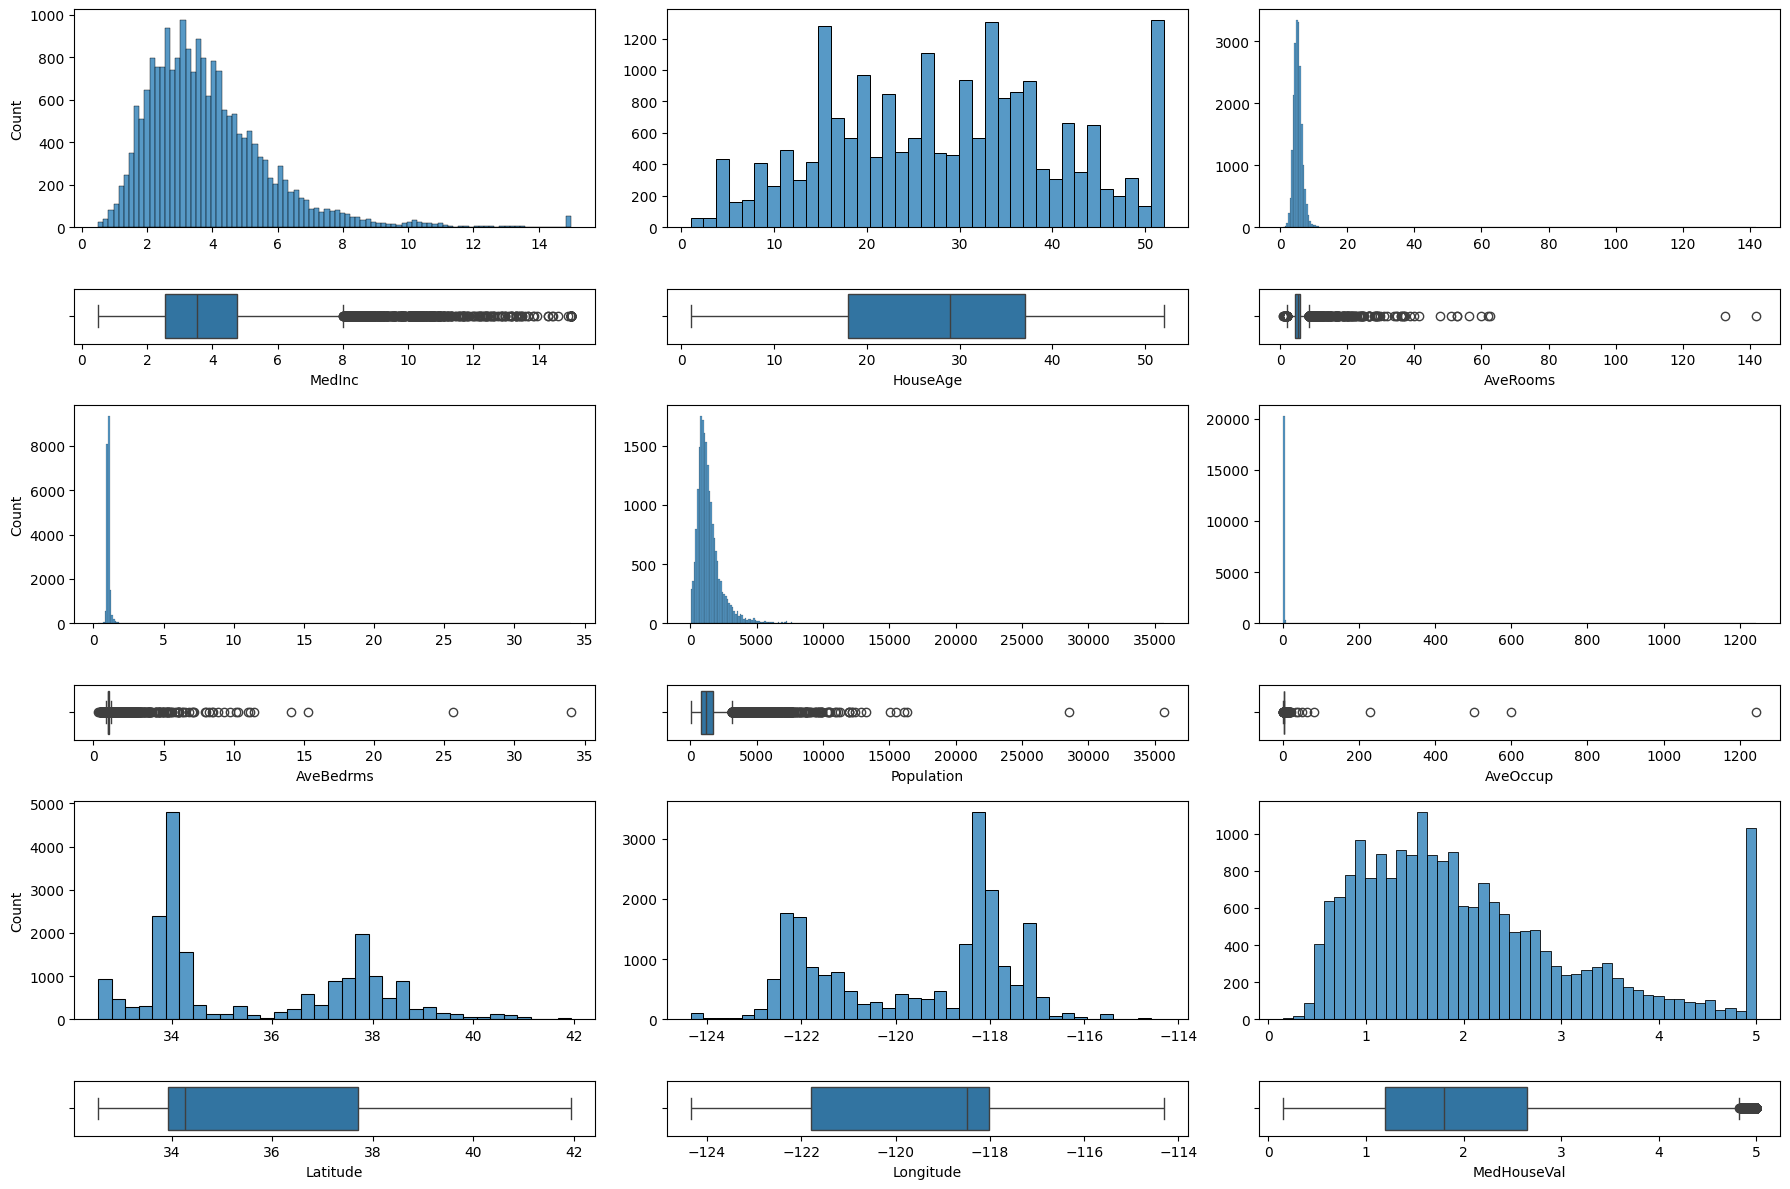

In [81]:
fig, axis = plt.subplots(6, 3, figsize = (18, 12), gridspec_kw={'height_ratios': [4, 1, 4, 1, 4, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = df, x = "MedInc").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "MedInc")

sns.histplot(ax = axis[0, 1], data = df, x = "HouseAge").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "HouseAge")

sns.histplot(ax = axis[0, 2], data = df, x = "AveRooms").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = df, x = "AveRooms")

sns.histplot(ax = axis[2, 0], data = df, x = "AveBedrms").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "AveBedrms")

sns.histplot(ax = axis[2, 1], data = df, x = "Population").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "Population")

sns.histplot(ax = axis[2, 2], data = df, x = "AveOccup").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 2], data = df, x = "AveOccup")

sns.histplot(ax = axis[4, 0], data = df, x = "Latitude").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = df, x = "Latitude")

sns.histplot(ax = axis[4, 1], data = df, x = "Longitude").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = df, x = "Longitude")

sns.histplot(ax = axis[4, 2], data = df, x = "MedHouseVal").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 2], data = df, x = "MedHouseVal")


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

## Análisis de variables multivariante

### Análisis numérico-numérico

Tomaremos el dato "MedHouseVal" como variable objetivo

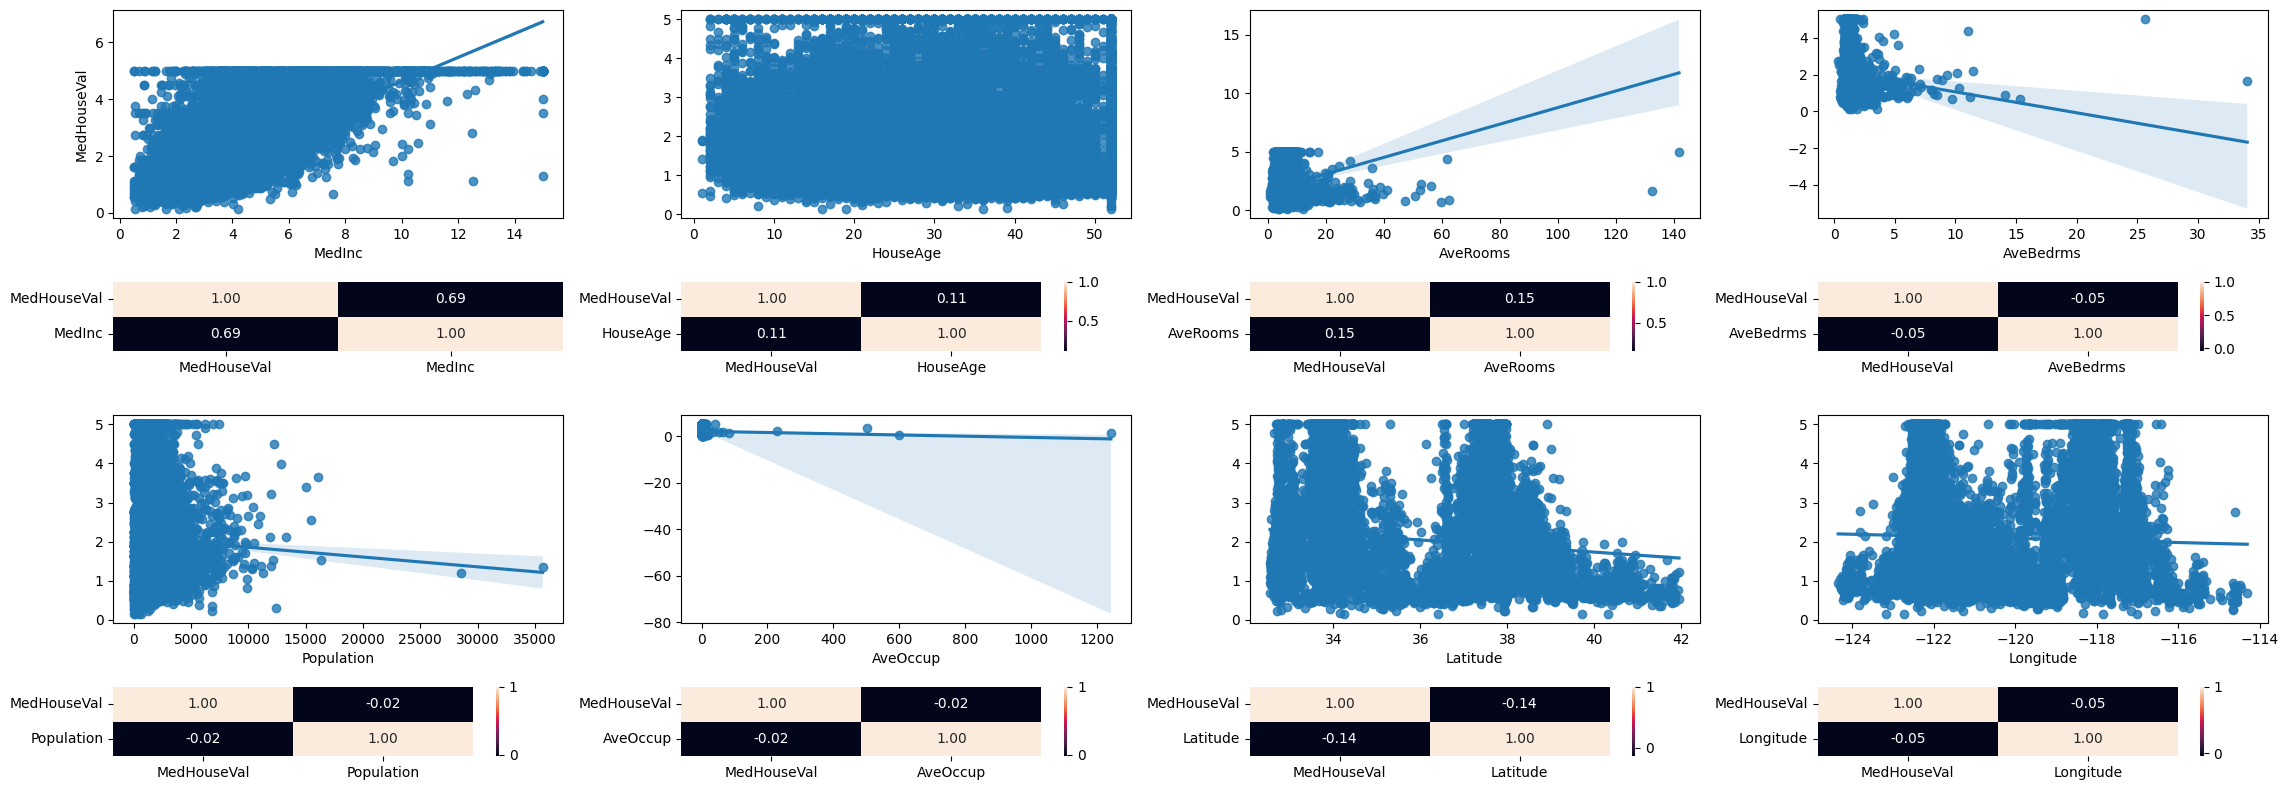

In [82]:
fig, axis = plt.subplots(4, 4, figsize = (23, 8), gridspec_kw={'height_ratios': [3, 1, 3, 1]})


# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "MedInc", y = "MedHouseVal")
sns.heatmap(df[["MedHouseVal", "MedInc"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "HouseAge", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "HouseAge"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[0, 2], data = df, x = "AveRooms", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "AveRooms"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2])

sns.regplot(ax = axis[0, 3], data = df, x = "AveBedrms", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "AveBedrms"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 3])

sns.regplot(ax = axis[2, 0], data = df, x = "Population", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "Population"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0])

sns.regplot(ax = axis[2, 1], data = df, x = "AveOccup", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "AveOccup"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1])

sns.regplot(ax = axis[2, 2], data = df, x = "Latitude", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "Latitude"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 2])

sns.regplot(ax = axis[2, 3], data = df, x = "Longitude", y = "MedHouseVal").set(ylabel=None)
sns.heatmap(df[["MedHouseVal", "Longitude"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 3])


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Combinaciones entre variables numéricas

Vamos a explorar la relación entre: MedInc con Latitude y Longitude, HouseAge con Population, MedInc con AveOccup, HouseAge con AveOccup, Population con AveOccup, AveRooms con AveBedrms

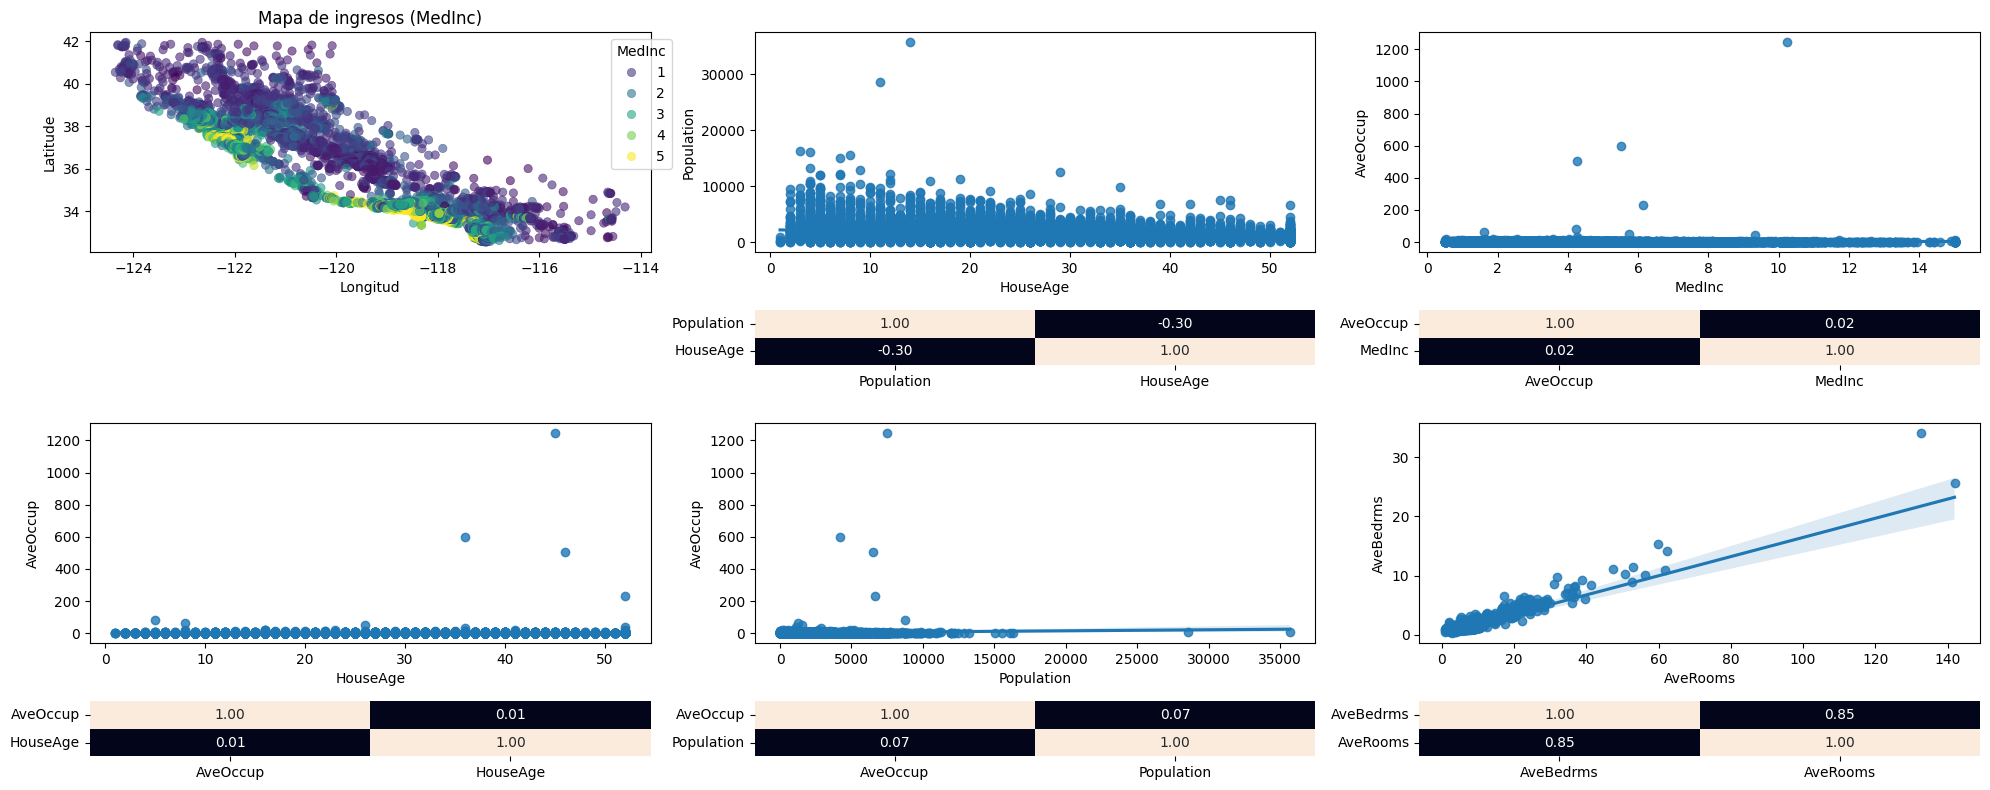

In [83]:
fig, axis = plt.subplots(4, 3, figsize = (20, 8), gridspec_kw={'height_ratios': [4, 1, 4, 1]})

# Crear un diagrama de dispersión múltiple

sns.scatterplot(ax = axis[0, 0], data = df, x = "Longitude", y = "Latitude", hue = "MedHouseVal", palette="viridis", alpha=0.6, edgecolor=None).set(title="Mapa de ingresos (MedInc)", xlabel = "Longitud", ylabel = "Latitude")
axis[0,0].legend(title='MedInc', bbox_to_anchor=(1.05, 1), loc='best')
fig.delaxes(axis[1,0])


sns.regplot(ax = axis[0, 1], data = df, x = "HouseAge", y = "Population")
sns.heatmap(df[["Population", "HouseAge"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(ax = axis[0, 2], data = df, x = "MedInc", y = "AveOccup")
sns.heatmap(df[["AveOccup", "MedInc"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2], cbar = False)



sns.regplot(ax = axis[2, 0], data = df, x = "HouseAge", y = "AveOccup")
sns.heatmap(df[["AveOccup", "HouseAge"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False)

sns.regplot(ax = axis[2, 1], data = df, x = "Population", y = "AveOccup")
sns.heatmap(df[["AveOccup", "Population"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False)

sns.regplot(ax = axis[2, 2], data = df, x = "AveRooms", y = "AveBedrms")
sns.heatmap(df[["AveBedrms", "AveRooms"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 2], cbar = False)



# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

## Análisis de correlaciones (completo)

#### Mapa de calor

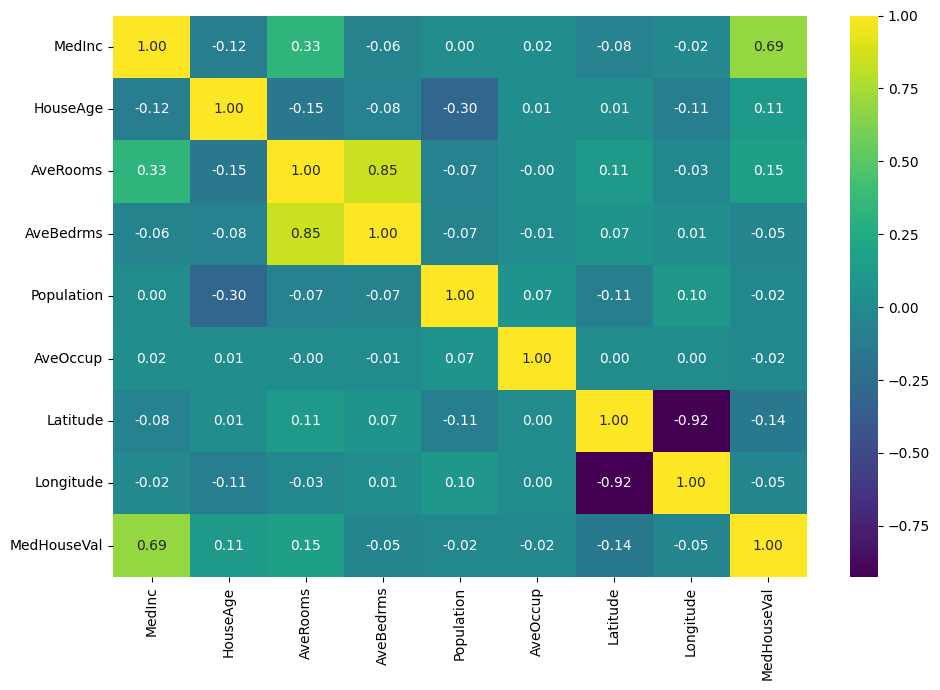

In [84]:
cols_num = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal']
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(df[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

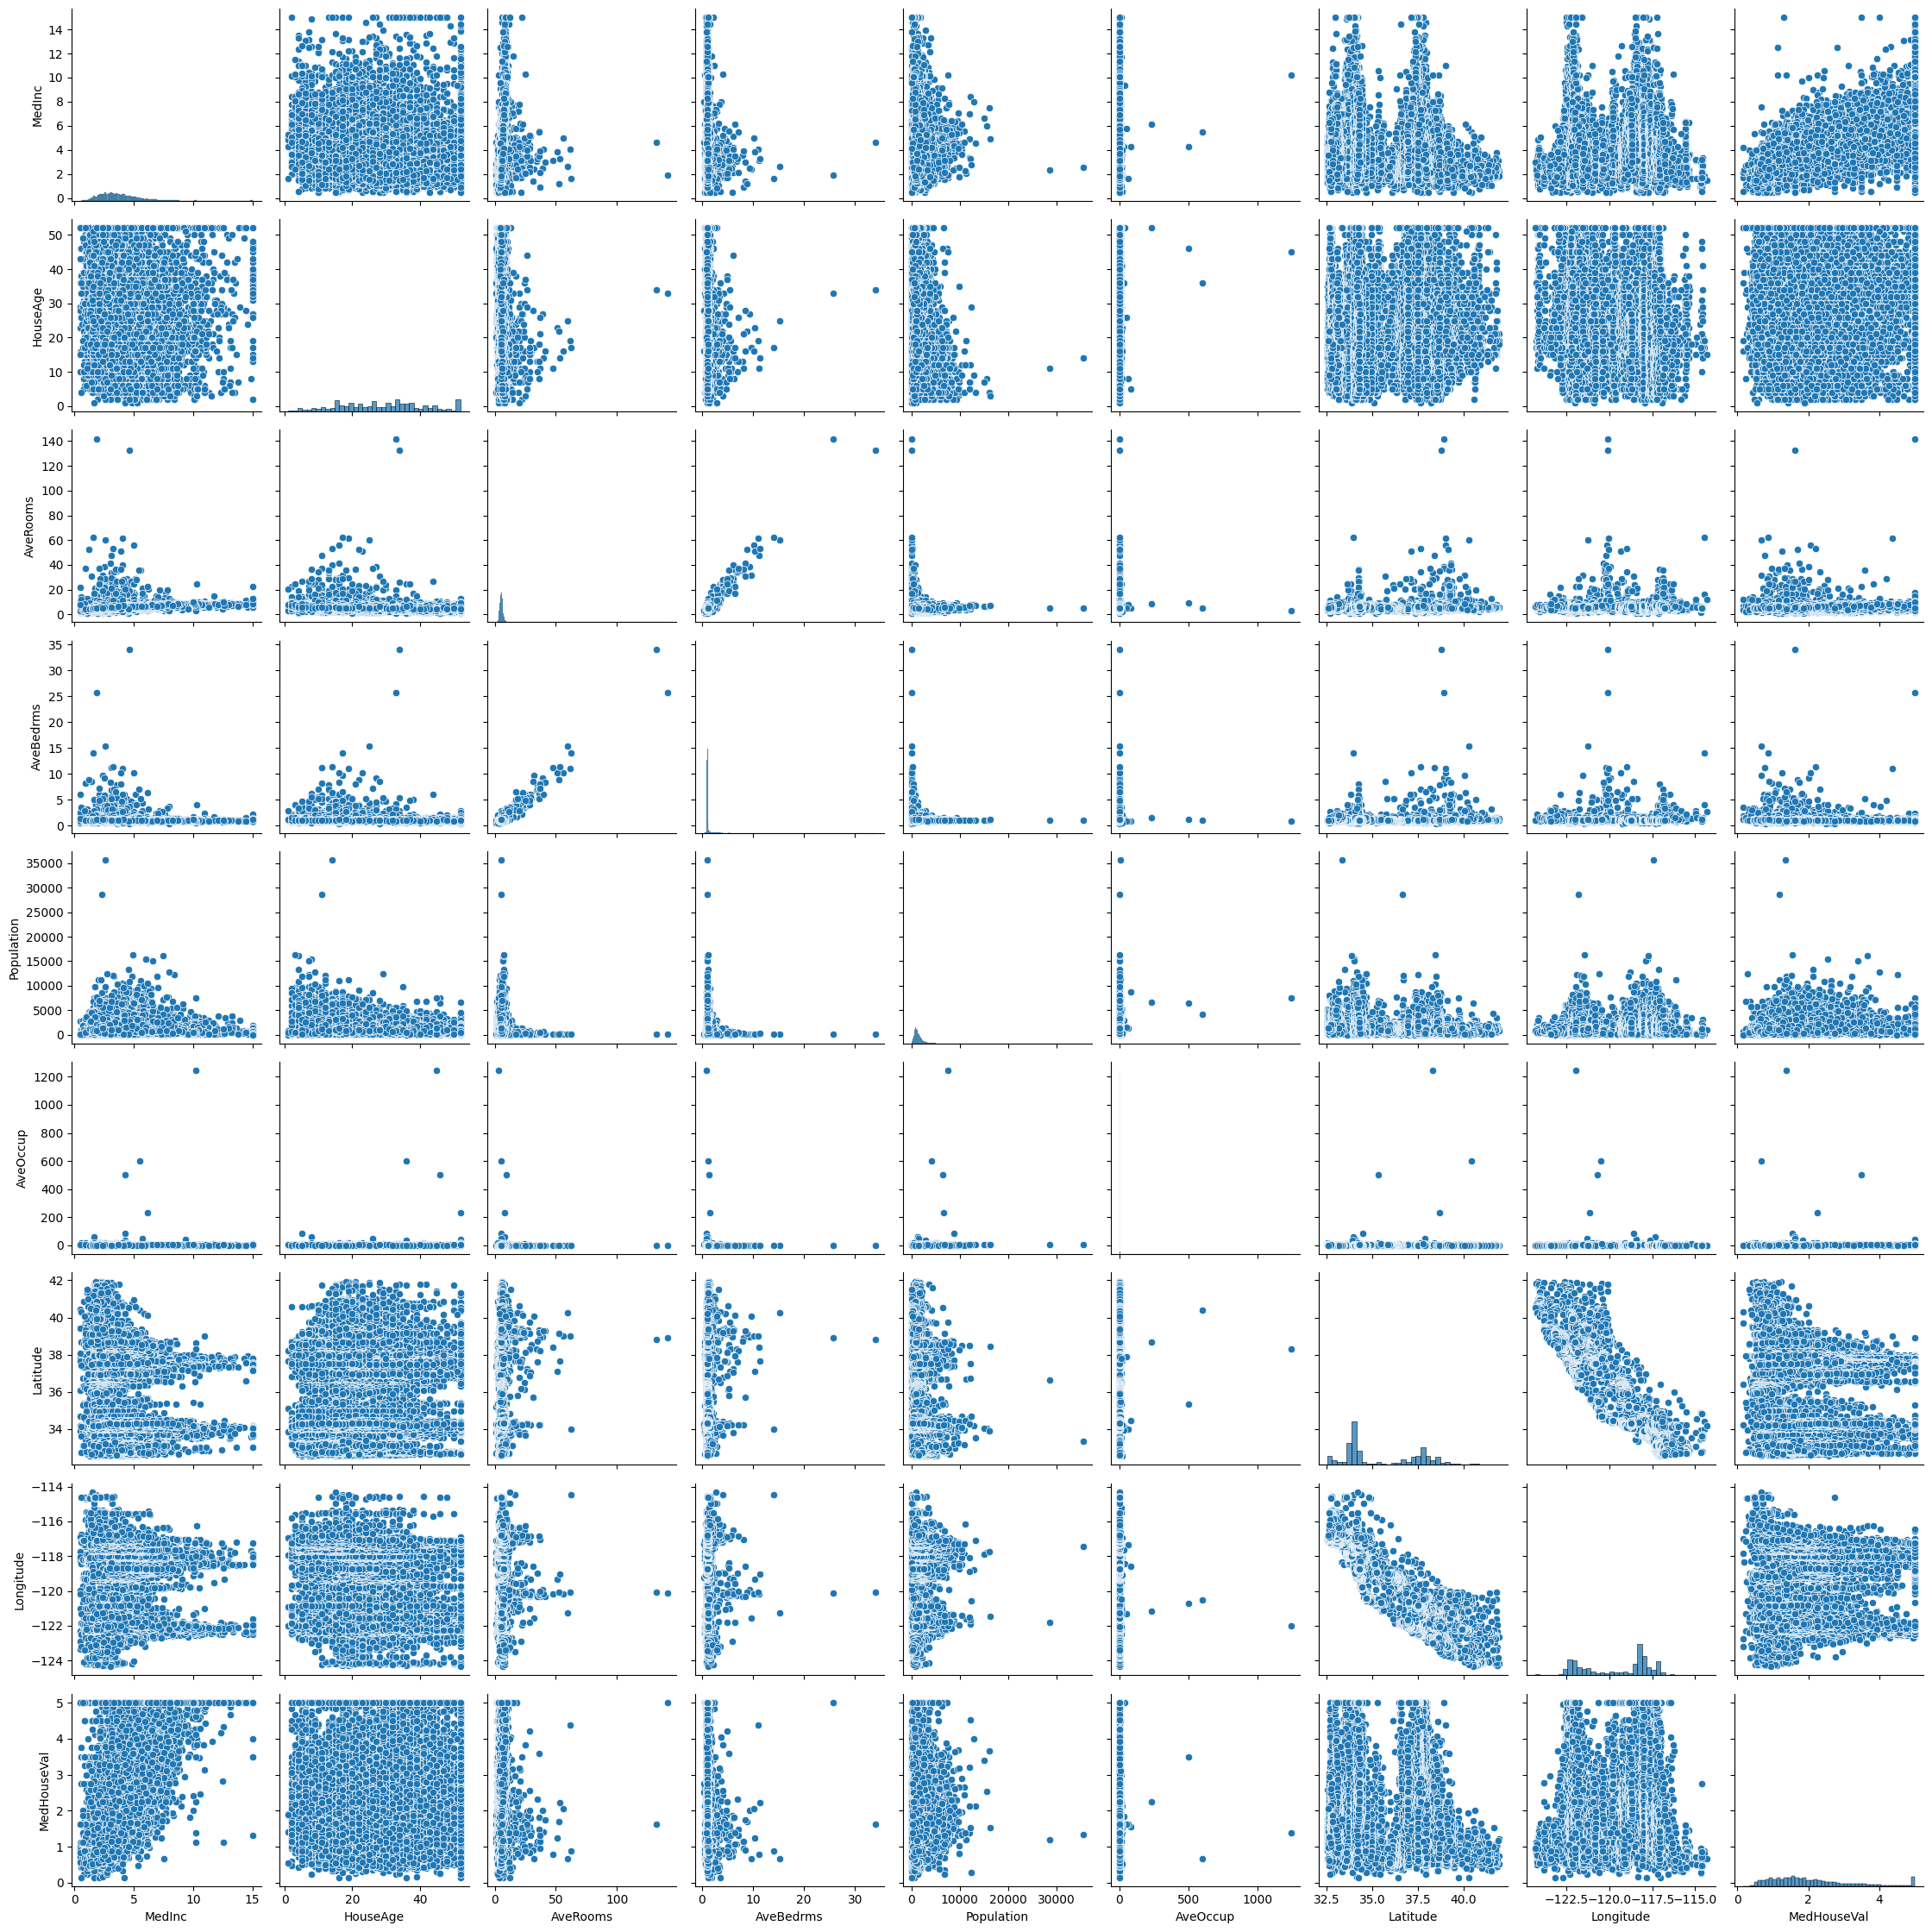

In [85]:
sns.pairplot(data = df)
plt.tight_layout()
plt.show()

## Feature engineering

### Análisis de outliers

In [86]:
FINAL_COLS = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal']
total_dataf = df[FINAL_COLS]
total_dataf.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [87]:
# Guardamos todos los datasets:

total_data_CON_outliers = total_dataf.copy()
total_data_SIN_outliers = total_dataf.copy()

outliers_cols = ["Population", "AveOccup"]

def replace_outliers(column, df):
  col_stats = total_dataf[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

with open("../data/processed/outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

### Análisis de valores faltantes

In [88]:
print(total_data_CON_outliers.isnull().sum().sort_values(ascending=False))
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

No hay valores faltantes o nulos

### Inferencia de nuevas características

### Escalado de valores

In [89]:
predictoras = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']
target = "MedHouseVal"

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)

In [90]:
# Normalización

norm_CON_outliers = StandardScaler()

norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

# SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


# ESCALADO MIN-MAX (MINMAXIMIZACIÓN)

scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

# SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)


# Guardado de los datasets resultantes
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel("../data/processed/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel("../data/processed/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel("../data/processed/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel("../data/processed/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel("../data/processed/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel("../data/processed/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel("../data/processed/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel("../data/processed/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel("../data/processed/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel("../data/processed/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel("../data/processed/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel("../data/processed/y_train.xlsx", index = False)
y_test.to_excel("../data/processed/y_test.xlsx", index = False)

# SCALERS

with open("../models/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open("../models/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open("../models/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open("../models/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)

## Feature Selection

In [91]:
X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

selection_model = SelectKBest(f_classif, k = 5)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,MedInc,HouseAge,Population,Latitude,Longitude
0,2.5212,21.0,3623.0,33.82,-116.52
1,2.6316,46.0,807.0,38.50,-122.94
2,5.1550,31.0,1472.0,37.63,-122.49
3,2.8229,16.0,1750.0,34.06,-118.11
4,1.9653,41.0,940.0,35.13,-120.66
